In [21]:
import os
import tensorflow as tf
import glob
import sys
import argparse
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_auc_score
import resnet_v1_eembc
import yaml
import csv
# from keras_flops import get_flops # (different flop calculation)
# import kerop
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers.experimental.preprocessing import RandomCrop
random_crop_model = tf.keras.models.Sequential()
random_crop_model.add(RandomCrop(32, 32, input_shape=(32, 32, 3,)))

import codecs
import pickle
from tensorflow.keras.losses import CategoricalCrossentropy
from fkeras.metrics.hessian import HessianMetrics
from fkeras.metrics.stat_fi import StatFI
import time

import numpy as np

def random_crop(x):
    return random_crop_model.predict(x)


def get_lr_schedule_func(initial_lr, lr_decay):

    def lr_schedule_func(epoch):
        return initial_lr * (lr_decay ** epoch)

    return lr_schedule_func


def yaml_load(config):
    with open(config) as stream:
        param = yaml.safe_load(stream)
    return param


In [22]:
#parser = argparse.ArgumentParser()
#parser.add_argument('-c', '--config', type=str, default="baseline.yml", help="specify yaml config")

#args = parser.parse_args()
config_file = './tiny2_pynq-z2-fkeras.yml' 

In [23]:
# parameters
config = yaml_load(config_file)
data_name = config['data']['name']
input_shape = [int(i) for i in config['data']['input_shape']]
num_classes = int(config['data']['num_classes'])
num_filters = config['model']['filters']
kernel_sizes = config['model']['kernels']
strides = config['model']['strides']
l1p = float(config['model']['l1'])
l2p = float(config['model']['l2'])
skip = bool(config['model']['skip'])
avg_pooling = bool(config['model']['avg_pooling'])
batch_size = config['fit']['batch_size']
num_epochs = config['fit']['epochs']
verbose = config['fit']['verbose']
patience = config['fit']['patience']
save_dir = config['save_dir']
model_name = config['model']['name']
loss = config['fit']['compile']['loss']
model_file_path = os.path.join(save_dir, 'model_best.h5')

# quantization parameters
if 'quantized' in model_name:
    logit_total_bits = config["quantization"]["logit_total_bits"]
    logit_int_bits = config["quantization"]["logit_int_bits"]
    activation_total_bits = config["quantization"]["activation_total_bits"]
    activation_int_bits = config["quantization"]["activation_int_bits"]
    alpha = config["quantization"]["alpha"]
    use_stochastic_rounding = config["quantization"]["use_stochastic_rounding"]
    logit_quantizer = config["quantization"]["logit_quantizer"]
    activation_quantizer = config["quantization"]["activation_quantizer"]
    final_activation = bool(config['model']['final_activation'])

# optimizer
optimizer = getattr(tf.keras.optimizers, config['fit']['compile']['optimizer'])
initial_lr = config['fit']['compile']['initial_lr']
lr_decay = config['fit']['compile']['lr_decay']

# load dataset
if data_name == 'cifar10':
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    X_train, X_test = X_train/256., X_test/256.

    y_train = tf.keras.utils.to_categorical(y_train, num_classes)
    y_test = tf.keras.utils.to_categorical(y_test, num_classes)

elif data_name == 'particlezoo':
    import particlezoo
    (X_train, y_train), (X_test, y_test) = particlezoo.load_data()
    X_train, X_test = X_train/256., X_test/256.

if loss == 'squared_hinge':
    y_train = y_train * 2 - 1  # -1 or 1 for hinge loss
    y_test = y_test * 2 - 1

# define data generator
if data_name == 'cifar10':
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        # preprocessing_function=random_crop,
        # brightness_range=(0.9, 1.2),
        # contrast_range=(0.9, 1.2)
    )
elif data_name == 'particlezoo':
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        # vertical_flip=True,
        # zca_whitening=True,
        # brightness_range=(0.9, 1.2),
        # contrast_range=(0.9, 1.2)
    )

# run preprocessing on training dataset
datagen.fit(X_train)

kwargs = {'input_shape': input_shape,
            'num_classes': num_classes,
            'num_filters': num_filters,
            'kernel_sizes': kernel_sizes,
            'strides': strides,
            'l1p': l1p,
            'l2p': l2p,
            'skip': skip,
            'avg_pooling': avg_pooling}

# pass quantization params
if 'quantized' in model_name:
    kwargs["logit_total_bits"] = logit_total_bits
    kwargs["logit_int_bits"] = logit_int_bits
    kwargs["activation_total_bits"] = activation_total_bits
    kwargs["activation_int_bits"] = activation_int_bits
    kwargs["alpha"] = None if alpha == 'None' else alpha
    kwargs["use_stochastic_rounding"] = use_stochastic_rounding
    kwargs["logit_quantizer"] = logit_quantizer
    kwargs["activation_quantizer"] = activation_quantizer
    kwargs["final_activation"] = final_activation

# define model
model = getattr(resnet_v1_eembc, model_name)(**kwargs)

# print model summary
print('#################')
print('# MODEL SUMMARY #')
print('#################')
print(model.summary())
print('#################')

# analyze FLOPs (see https://github.com/kentaroy47/keras-Opcounter)
# layer_name, layer_flops, inshape, weights = kerop.profile(model)

# # visualize FLOPs results
# total_flop = 0
# for name, flop, shape in zip(layer_name, layer_flops, inshape):
#     print("layer:", name, shape, " MFLOPs:", flop/1e6)
#     total_flop += flop
# print("Total FLOPs: {} MFLOPs".format(total_flop/1e6))

# tf.keras.utils.plot_model(model,
#                           to_file="model.png",
#                           show_shapes=True,
#                           show_dtype=False,
#                           show_layer_names=False,
#                           rankdir="TB",
#                           expand_nested=False)

# Alternative FLOPs calculation (see https://github.com/tokusumi/keras-flops), ~same answer
# total_flop = get_flops(model, batch_size=1)
# print("FLOPS: {} GLOPs".format(total_flop/1e9))

# compile model with optimizer
model.compile(optimizer=optimizer(learning_rate=initial_lr),
                loss=loss,
                metrics=['accuracy'])

# callbacks
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler

# lr_schedule_func = get_lr_schedule_func(initial_lr, lr_decay)

# callbacks = [ModelCheckpoint(model_file_path, monitor='val_accuracy', verbose=verbose, save_best_only=True),
#              EarlyStopping(monitor='val_accuracy', patience=patience, verbose=verbose, restore_best_weights=True),
#              LearningRateScheduler(lr_schedule_func, verbose=verbose),
#              ]

# # train
# history = model.fit(datagen.flow(X_train, y_train, batch_size=batch_size),
#                     steps_per_epoch=X_train.shape[0] // batch_size,
#                     epochs=num_epochs,
#                     validation_data=(X_test, y_test),
#                     callbacks=callbacks,
#                     verbose=verbose)

# restore "best" model
model.load_weights(model_file_path)

# Evaluate the model
print("Computing Hessian Metrics...")

hess = HessianMetrics(
    model, 
    CategoricalCrossentropy(), 
    X_test[:256], 
    y_test[:256],
    batch_size=32
)
    
hess_start = time.time()
top_k = 8
BIT_WIDTH = 8
strategy = "sum"
# Hessian model-wide sensitivity ranking
eigenvalues, eigenvectors = hess.top_k_eigenvalues(k=top_k, max_iter=500, rank_BN=False)


print(f'Hessian eigenvalue compute time: {time.time() - hess_start} seconds\n')
# eigenvalues = None
rank_start_time = time.time()

param_ranking, param_scores = hess.hessian_ranking_general(
    eigenvectors, eigenvalues=eigenvalues, k=top_k, strategy=strategy, iter_by=1
)

# Hessian param ranking + quantizer_info for hybrid Hessian + BinFI analysis
#Extract model parameters
sfi_model = StatFI(model)
params_and_quants = sfi_model.get_params_and_quantizers()
print(f"{params_and_quants[0].shape}")
print(f"{params_and_quants[1].shape}")
quantizer_info = params_and_quants[1][0]

#################
# MODEL SUMMARY #
#################
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 fq_conv2d (FQConv2D)        (None, 32, 32, 32)        128       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 q_activation (QActivation)  (None, 32, 32, 32)        0         
                                                                 
 fq_conv2d_1 (FQConv2D)      (None, 32, 32, 4)         2052      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 4)         16        
 chNorm

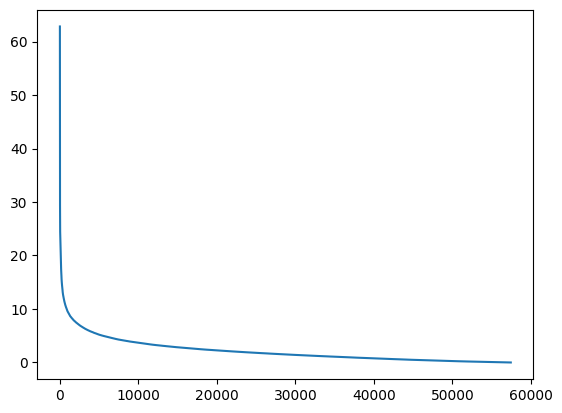

In [26]:
import matplotlib.pyplot as plt 
plt.plot(param_scores)

In [61]:
params = []

# Sanitize params 
# Get indices of parameters in supported layers
supported_indices = hess.get_supported_layer_indices()

for i in hess.layer_indices:
    print(f'Layer {i}: {hess.model.layers[i].name}')
    # Get trainable vars for this layer 
    layer_params = hess.model.layers[i].trainable_variables
    print(f'\ttrainable vars: {[v.shape for v in layer_params]}')
    params.append(layer_params)


# Sanitize params (i.e., remove any params from unsupported layers)
sanitized_params = list()
for i in range(len(params)):
    if i in supported_indices:
        sanitized_params.append(np.array(params[i]))
        print(f'Layer {i} is supported')
    else:
        print(f'Layer {i} is not supported')

params = sanitized_params

# Flatten and concatenate all eigenvectors into one list
params = np.concatenate(params, axis=None)
params = params.flatten()

k = 1


Layer 1: fq_conv2d
	trainable vars: [TensorShape([1, 1, 3, 32]), TensorShape([32])]
Layer 2: batch_normalization
	trainable vars: [TensorShape([32]), TensorShape([32])]
Layer 4: fq_conv2d_1
	trainable vars: [TensorShape([4, 4, 32, 4]), TensorShape([4])]
Layer 5: batch_normalization_1
	trainable vars: [TensorShape([4]), TensorShape([4])]
Layer 7: fq_conv2d_2
	trainable vars: [TensorShape([4, 4, 4, 32]), TensorShape([32])]
Layer 8: batch_normalization_2
	trainable vars: [TensorShape([32]), TensorShape([32])]
Layer 10: fq_conv2d_3
	trainable vars: [TensorShape([4, 4, 32, 32]), TensorShape([32])]
Layer 11: batch_normalization_3
	trainable vars: [TensorShape([32]), TensorShape([32])]
Layer 13: fq_conv2d_4
	trainable vars: [TensorShape([4, 4, 32, 32]), TensorShape([32])]
Layer 14: batch_normalization_4
	trainable vars: [TensorShape([32]), TensorShape([32])]
Layer 17: fq_dense
	trainable vars: [TensorShape([2048, 10]), TensorShape([10])]
Layer 0 is supported
Layer 1 is not supported
Layer 2 i

/tmp/ipykernel_3784948/1111839964.py:19: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sanitized_params.append(np.array(params[i]))


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [63]:
param_ranking

(57440,)

In [64]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 fq_conv2d (FQConv2D)        (None, 32, 32, 32)        128       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 q_activation (QActivation)  (None, 32, 32, 32)        0         
                                                                 
 fq_conv2d_1 (FQConv2D)      (None, 32, 32, 4)         2052      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 4)         16        
 chNormalization)                                            